# Módulo 3. Visualización y análisis exploratorio para investigación social aplicada

**Curso:** Fundamentos de Programación para IA Generativa Aplicada  
**Orientación:** Ciencias sociales aplicadas  
**Sesión:** 3

---

## Propósito del módulo

En esta sesión trabajaremos la visualización de datos no como una práctica ornamental, sino como una fase de análisis exploratorio y comparación sustantiva. Usaremos directamente las bases construidas en el módulo 2 para: describir la evolución de indicadores clave en Cusco; comparar a Cusco con el agregado nacional; ubicar a Cusco dentro de la distribución departamental; explorar relaciones entre ingreso, pobreza por NBI, participación y contexto macroeconómico; y producir gráficos exportables para la Tarea 1.

---

## Idea central

Visualizar no es “hacer gráficos bonitos”. Visualizar es construir una representación que: preserve la estructura del problema, permita comparaciones válidas, y haga legible una pregunta empírica. En esta lógica, un gráfico es una transformación analítica del dato, no un adorno final.

## 1. Principio metodológico de la sesión

Antes de graficar, debemos recordar tres reglas:

1. **Todo gráfico responde a una pregunta.**
   Si no hay pregunta, el gráfico suele ser decorativo.

2. **La forma del gráfico depende de la estructura del dato.**
   - tiempo → líneas;
   - comparación entre grupos → barras o puntos;
   - distribución → histogramas/boxplots;
   - relación entre variables → dispersión;
   - múltiples indicadores → heatmap con cautela.

3. **Visualizar no equivale a explicar causalmente.**
   Un patrón visible puede sugerir hipótesis, pero no prueba mecanismos por sí mismo.

En esta sesión, por tanto, trabajaremos con visualizaciones orientadas por pregunta.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="talk")

In [3]:
# Rutas de trabajo

RUTA_RESULTADOS_S2 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2")
RUTA_RESULTADOS_S3 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 3")

RUTA_RESULTADOS_S3.mkdir(parents=True, exist_ok=True)

if not RUTA_RESULTADOS_S2.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de resultados de la sesión 2:\n{RUTA_RESULTADOS_S2}"
    )

print("Lectura desde :", RUTA_RESULTADOS_S2)
print("Exportación a :", RUTA_RESULTADOS_S3)

Lectura desde : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2
Exportación a : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 3


In [4]:
# Archivos esperados desde la sesión 2

ARCHIVOS = {
    "hogar_panel": RUTA_RESULTADOS_S2 / "enaho_hogar_panel_2021_2024.csv",
    "panel_dpto": RUTA_RESULTADOS_S2 / "panel_dpto_2021_2024.csv",
    "base_final": RUTA_RESULTADOS_S2 / "base_final_2021_2024_pib.csv",
    "base_cusco": RUTA_RESULTADOS_S2 / "base_cusco_2021_2024.csv",
}

for nombre, ruta in ARCHIVOS.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo esperado: {ruta}")
    print(f"{nombre}: OK")

hogar_panel: OK
panel_dpto: OK
base_final: OK
base_cusco: OK


In [5]:
# Cargar datos

enaho_hogar_panel = pd.read_csv(ARCHIVOS["hogar_panel"])
panel_dpto = pd.read_csv(ARCHIVOS["panel_dpto"])
base_final = pd.read_csv(ARCHIVOS["base_final"])
base_cusco = pd.read_csv(ARCHIVOS["base_cusco"])

print("Dimensiones:")
print("enaho_hogar_panel:", enaho_hogar_panel.shape)
print("panel_dpto      :", panel_dpto.shape)
print("base_final      :", base_final.shape)
print("base_cusco      :", base_cusco.shape)

Dimensiones:
enaho_hogar_panel: (176755, 24)
panel_dpto      : (100, 14)
base_final      : (100, 16)
base_cusco      : (4, 16)


In [6]:
# Conversión prudente de tipos

columnas_numericas = [
    "anio", "n_hogares", "pct_hogares_ingreso_obs", "ingreso_prom_hogar",
    "ingreso_mediano_hogar", "ln_ingreso_prom_hogar", "pct_hogares_con_superior",
    "pct_hogares_con_universitaria", "pct_hogares_participa", "n_org_prom_hogar",
    "pct_pobre_nbi", "nbi_prom", "pib", "pib_crecimiento"
]

for df in [panel_dpto, base_final, base_cusco]:
    for col in columnas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

base_final["cod_dpto"] = base_final["cod_dpto"].astype("string").str.zfill(2)
base_cusco["cod_dpto"] = base_cusco["cod_dpto"].astype("string").str.zfill(2)

In [7]:
# Auditoría mínima antes de graficar

def auditoria_visual(df, nombre):
    print(f"\n{nombre}")
    print("-" * len(nombre))
    print("Forma:", df.shape)
    print("Missings principales:")
    cols = [c for c in ["ingreso_prom_hogar", "pct_pobre_nbi", "pct_hogares_participa", "pct_hogares_con_superior", "pib", "pib_crecimiento"] if c in df.columns]
    print(df[cols].isna().sum())
    display(df.head())

auditoria_visual(base_cusco, "base_cusco")
auditoria_visual(base_final, "base_final")


base_cusco
----------
Forma: (4, 16)
Missings principales:
ingreso_prom_hogar          0
pct_pobre_nbi               0
pct_hogares_participa       0
pct_hogares_con_superior    0
pib                         0
pib_crecimiento             1
dtype: int64


,cod_dpto,anio,n_hogares,pct_hogares_ingreso_obs,ingreso_prom_hogar,ingreso_mediano_hogar,ln_ingreso_prom_hogar,pct_hogares_con_superior,pct_hogares_con_universitaria,pct_hogares_participa,n_org_prom_hogar,pct_pobre_nbi,nbi_prom,departamento,pib,pib_crecimiento
0,08,2021,1643,0.344,"21,037.003","14,841.702",9.478,0.367,0.228,0.642,0.716,0.110,0.129,Cusco,"20,592,202.000",NaN
1,08,2022,1655,0.367,"21,960.449","15,342.000",9.535,0.368,0.231,0.659,0.736,0.109,0.117,Cusco,"21,489,757.000",4.359
2,08,2023,1658,0.365,"22,846.755","18,057.000",9.637,0.381,0.231,0.689,0.820,0.109,0.121,Cusco,"22,507,388.000",4.735
3,08,2024,1765,0.350,"26,348.057","19,272.000",9.756,0.411,0.246,0.709,0.912,0.104,0.112,Cusco,"22,767,865.000",1.157



base_final
----------
Forma: (100, 16)
Missings principales:
ingreso_prom_hogar           0
pct_pobre_nbi                0
pct_hogares_participa        0
pct_hogares_con_superior     0
pib                          0
pib_crecimiento             25
dtype: int64


,cod_dpto,anio,n_hogares,pct_hogares_ingreso_obs,ingreso_prom_hogar,ingreso_mediano_hogar,ln_ingreso_prom_hogar,pct_hogares_con_superior,pct_hogares_con_universitaria,pct_hogares_participa,n_org_prom_hogar,pct_pobre_nbi,nbi_prom,departamento,pib,pib_crecimiento
0,01,2021,1516,0.413,"16,707.210","9,677.985",9.162,0.290,0.151,0.664,0.864,0.272,0.360,Amazonas,"3,122,772.000",NaN
1,01,2022,1553,0.394,"17,362.056","11,487.500",9.273,0.274,0.146,0.688,0.922,0.282,0.356,Amazonas,"3,064,074.000",-1.880
2,01,2023,1548,0.399,"16,481.181","11,139.000",9.251,0.291,0.138,0.736,1.119,0.294,0.387,Amazonas,"3,124,439.000",1.970
3,01,2024,1583,0.389,"18,200.894","10,849.000",9.264,0.286,0.142,0.690,1.052,0.298,0.382,Amazonas,"3,103,841.000",-0.659
4,02,2021,1748,0.432,"19,872.371","13,840.217",9.333,0.378,0.255,0.470,0.791,0.157,0.172,Áncash,"21,466,272.000",NaN


## 2. Preparación de variables para visualización

Muchas variables del módulo 2 están en proporciones entre 0 y 1.  
Para fines gráficos y comunicativos, conviene expresarlas también en porcentaje. Esto no cambia la estructura del dato; solo cambia su escala de lectura.

In [8]:
# Crear copias de trabajo para visualización

viz_cusco = base_cusco.copy()
viz_dpto = base_final.copy()

cols_prop = [
    "pct_hogares_ingreso_obs",
    "pct_hogares_con_superior",
    "pct_hogares_con_universitaria",
    "pct_hogares_participa",
    "pct_pobre_nbi"
]

for col in cols_prop:
    if col in viz_cusco.columns:
        viz_cusco[col + "_100"] = viz_cusco[col] * 100
    if col in viz_dpto.columns:
        viz_dpto[col + "_100"] = viz_dpto[col] * 100

display(viz_cusco)

,cod_dpto,anio,n_hogares,pct_hogares_ingreso_obs,ingreso_prom_hogar,ingreso_mediano_hogar,ln_ingreso_prom_hogar,pct_hogares_con_superior,pct_hogares_con_universitaria,pct_hogares_participa,n_org_prom_hogar,pct_pobre_nbi,nbi_prom,departamento,pib,pib_crecimiento,pct_hogares_ingreso_obs_100,pct_hogares_con_superior_100,pct_hogares_con_universitaria_100,pct_hogares_participa_100,pct_pobre_nbi_100
0,08,2021,1643,0.344,"21,037.003","14,841.702",9.478,0.367,0.228,0.642,0.716,0.110,0.129,Cusco,"20,592,202.000",NaN,34.450,36.700,22.800,64.180,11.040
1,08,2022,1655,0.367,"21,960.449","15,342.000",9.535,0.368,0.231,0.659,0.736,0.109,0.117,Cusco,"21,489,757.000",4.359,36.740,36.820,23.110,65.860,10.870
2,08,2023,1658,0.365,"22,846.755","18,057.000",9.637,0.381,0.231,0.689,0.820,0.109,0.121,Cusco,"22,507,388.000",4.735,36.490,38.070,23.120,68.870,10.870
3,08,2024,1765,0.350,"26,348.057","19,272.000",9.756,0.411,0.246,0.709,0.912,0.104,0.112,Cusco,"22,767,865.000",1.157,34.960,41.140,24.630,70.890,10.410


In [9]:
# Funciones auxiliares para graficar y exportar

def guardar_fig(fig, nombre_archivo):
    ruta = RUTA_RESULTADOS_S3 / nombre_archivo
    fig.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Gráfico exportado: {ruta.name}")


def resaltar_cusco(ax, x, y, data, etiqueta_col="departamento", color_resalte="crimson"):
    subset = data[data["cod_dpto"] == "08"].copy()
    if len(subset) > 0:
        ax.scatter(subset[x], subset[y], s=120, zorder=5)
        for _, row in subset.iterrows():
            ax.annotate(
                row[etiqueta_col],
                (row[x], row[y]),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=10
            )

## 3. Serie temporal de Cusco

La primera pregunta correcta es simple: **¿Cómo evolucionan, entre 2021 y 2024, algunos indicadores centrales de Cusco?** No conviene mezclar demasiadas series en una sola figura. Para mantener legibilidad, trabajaremos con gráficos separados pero estilísticamente consistentes.

Gráfico exportado: 01_cusco_ingreso_promedio_hogar_2021_2024.png


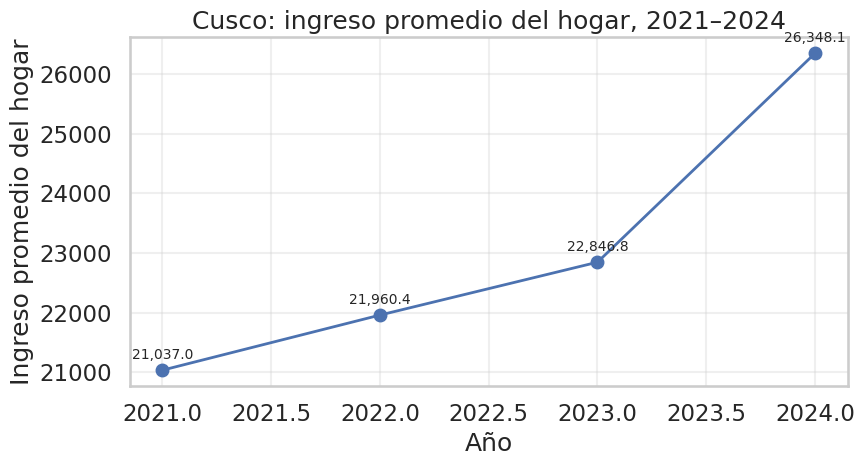

In [10]:
# Orden temporal

viz_cusco = viz_cusco.sort_values("anio").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["ingreso_prom_hogar"], marker="o", linewidth=2)
ax.set_title("Cusco: ingreso promedio del hogar, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Ingreso promedio del hogar")
ax.grid(True, alpha=0.3)

for x, y in zip(viz_cusco["anio"], viz_cusco["ingreso_prom_hogar"]):
    ax.annotate(f"{y:,.1f}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
guardar_fig(fig, "01_cusco_ingreso_promedio_hogar_2021_2024.png")
plt.show()

Gráfico exportado: 02_cusco_pct_pobre_nbi_2021_2024.png


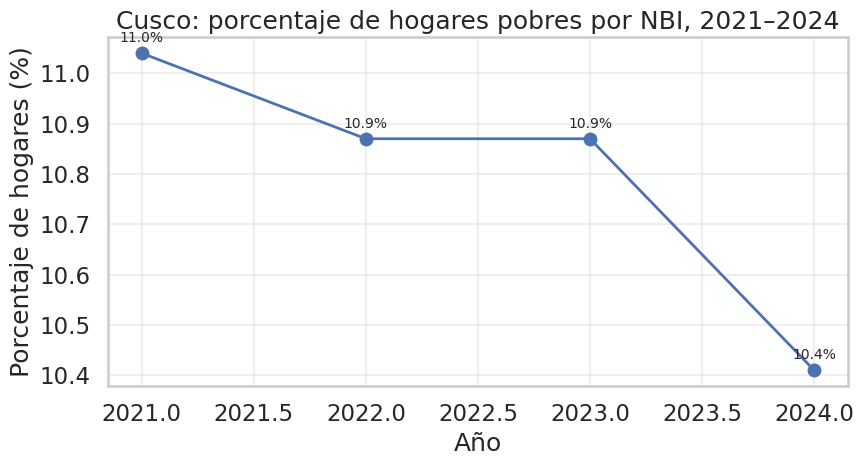

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["pct_pobre_nbi_100"], marker="o", linewidth=2)
ax.set_title("Cusco: porcentaje de hogares pobres por NBI, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de hogares (%)")
ax.grid(True, alpha=0.3)

for x, y in zip(viz_cusco["anio"], viz_cusco["pct_pobre_nbi_100"]):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
guardar_fig(fig, "02_cusco_pct_pobre_nbi_2021_2024.png")
plt.show()

Gráfico exportado: 03_cusco_participacion_y_educacion_superior_2021_2024.png


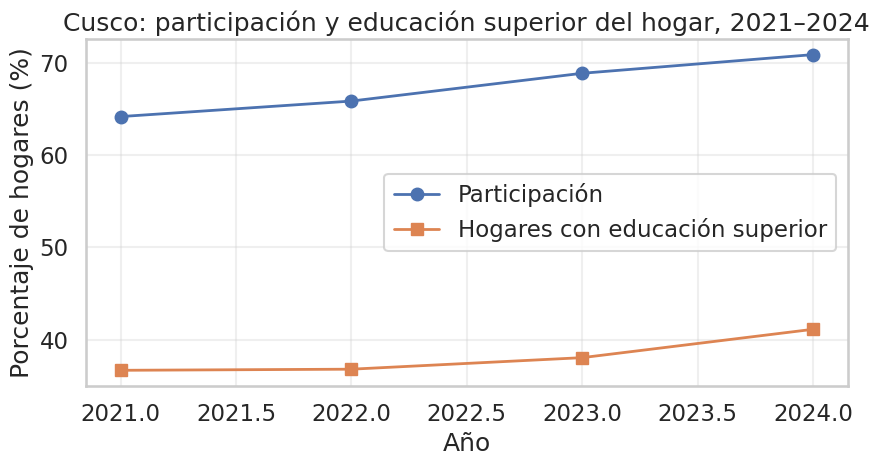

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["pct_hogares_participa_100"], marker="o", linewidth=2, label="Participación")
ax.plot(viz_cusco["anio"], viz_cusco["pct_hogares_con_superior_100"], marker="s", linewidth=2, label="Hogares con educación superior")
ax.set_title("Cusco: participación y educación superior del hogar, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de hogares (%)")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "03_cusco_participacion_y_educacion_superior_2021_2024.png")
plt.show()

Gráfico exportado: 04_cusco_crecimiento_pib_2021_2024.png


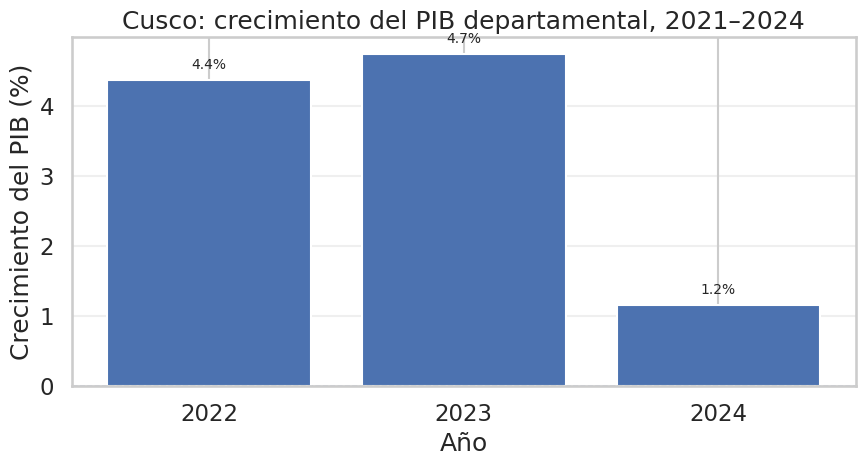

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(viz_cusco["anio"].astype(str), viz_cusco["pib_crecimiento"])
ax.set_title("Cusco: crecimiento del PIB departamental, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Crecimiento del PIB (%)")
ax.axhline(0, linestyle="--", linewidth=1)
ax.grid(True, axis="y", alpha=0.3)

for x, y in zip(viz_cusco["anio"].astype(str), viz_cusco["pib_crecimiento"]):
    if pd.notna(y):
        ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 8 if y >= 0 else -14), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
guardar_fig(fig, "04_cusco_crecimiento_pib_2021_2024.png")
plt.show()

## 4. Comparación Cusco vs Perú

Una pregunta más fuerte es: **¿Cusco sigue una trayectoria similar al agregado nacional o presenta un comportamiento diferenciado?** Para responderla, construiremos un agregado Perú directamente desde la base hogar × año, manteniendo consistencia con las variables ya definidas.

In [14]:
# Construcción del agregado Perú desde la base hogar × año

for col in [
    "ingreso_hogar_total", "hogar_con_superior", "hogar_con_universitaria",
    "hogar_participa", "n_org_hogar", "pobre_nbi", "n_nbi", "anio"
]:
    if col in enaho_hogar_panel.columns:
        enaho_hogar_panel[col] = pd.to_numeric(enaho_hogar_panel[col], errors="coerce")

peru_anual = (
    enaho_hogar_panel
    .groupby("anio", as_index=False)
    .agg(
        ingreso_prom_hogar=("ingreso_hogar_total", "mean"),
        ingreso_mediano_hogar=("ingreso_hogar_total", "median"),
        pct_hogares_con_superior=("hogar_con_superior", "mean"),
        pct_hogares_con_universitaria=("hogar_con_universitaria", "mean"),
        pct_hogares_participa=("hogar_participa", "mean"),
        pct_pobre_nbi=("pobre_nbi", "mean"),
        nbi_prom=("n_nbi", "mean")
    )
)

for col in ["pct_hogares_con_superior", "pct_hogares_con_universitaria", "pct_hogares_participa", "pct_pobre_nbi"]:
    peru_anual[col + "_100"] = peru_anual[col] * 100

display(peru_anual)

,anio,ingreso_prom_hogar,ingreso_mediano_hogar,pct_hogares_con_superior,pct_hogares_con_universitaria,pct_hogares_participa,pct_pobre_nbi,nbi_prom,pct_hogares_con_superior_100,pct_hogares_con_universitaria_100,pct_hogares_participa_100,pct_pobre_nbi_100
0,2021,"23,369.872","16,085.971",0.416,0.254,0.415,0.171,0.202,41.571,25.382,41.493,17.071
1,2022,"25,015.760","17,921.000",0.425,0.259,0.431,0.171,0.200,42.504,25.900,43.147,17.087
2,2023,"26,605.440","18,681.000",0.435,0.262,0.458,0.172,0.205,43.478,26.250,45.789,17.199
3,2024,"28,047.298","19,813.000",0.444,0.268,0.456,0.165,0.196,44.417,26.806,45.629,16.524


Gráfico exportado: 05_cusco_vs_peru_ingreso_promedio_hogar.png


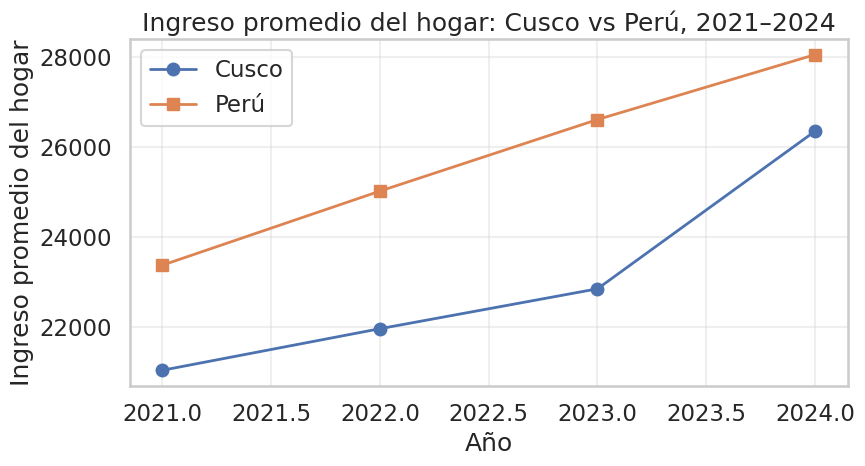

In [15]:
# Comparación Cusco vs Perú: ingreso promedio

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["ingreso_prom_hogar"], marker="o", linewidth=2, label="Cusco")
ax.plot(peru_anual["anio"], peru_anual["ingreso_prom_hogar"], marker="s", linewidth=2, label="Perú")
ax.set_title("Ingreso promedio del hogar: Cusco vs Perú, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Ingreso promedio del hogar")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "05_cusco_vs_peru_ingreso_promedio_hogar.png")
plt.show()

Gráfico exportado: 06_cusco_vs_peru_pobreza_nbi.png


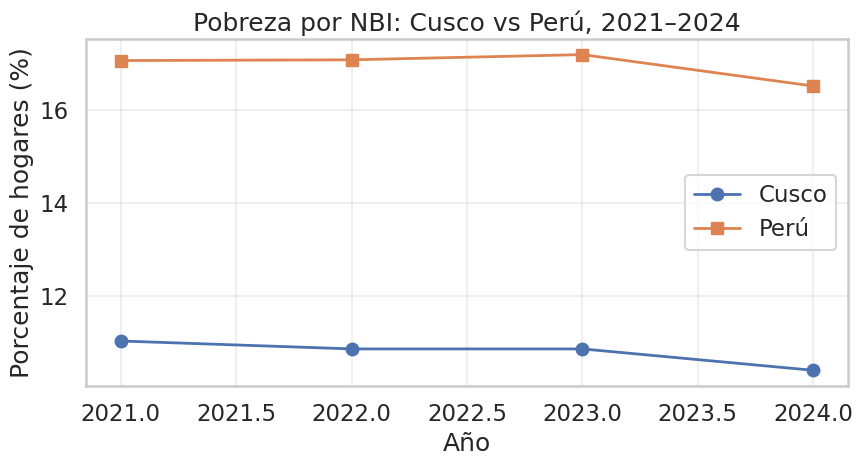

In [16]:
# Comparación Cusco vs Perú: pobreza por NBI

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["pct_pobre_nbi_100"], marker="o", linewidth=2, label="Cusco")
ax.plot(peru_anual["anio"], peru_anual["pct_pobre_nbi_100"], marker="s", linewidth=2, label="Perú")
ax.set_title("Pobreza por NBI: Cusco vs Perú, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de hogares (%)")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "06_cusco_vs_peru_pobreza_nbi.png")
plt.show()

Gráfico exportado: 07_cusco_vs_peru_participacion_hogar.png


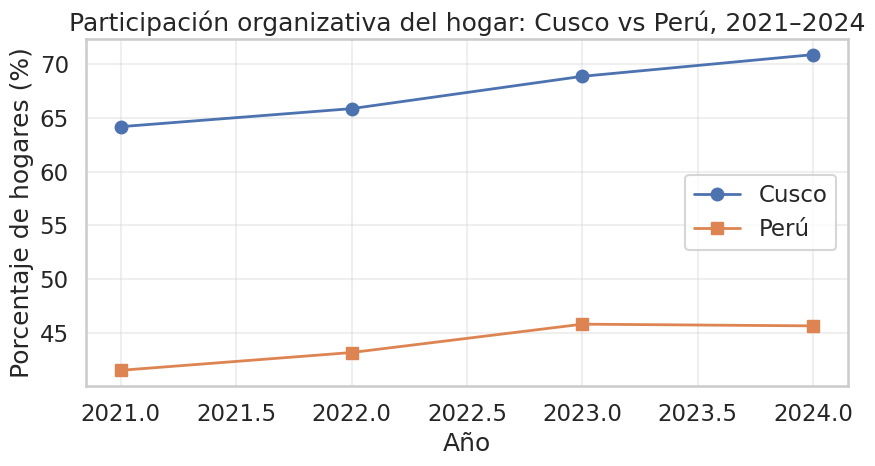

In [17]:
# Comparación Cusco vs Perú: participación del hogar

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(viz_cusco["anio"], viz_cusco["pct_hogares_participa_100"], marker="o", linewidth=2, label="Cusco")
ax.plot(peru_anual["anio"], peru_anual["pct_hogares_participa_100"], marker="s", linewidth=2, label="Perú")
ax.set_title("Participación organizativa del hogar: Cusco vs Perú, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de hogares (%)")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "07_cusco_vs_peru_participacion_hogar.png")
plt.show()

## 5. Posición relativa de Cusco dentro del conjunto departamental

Ahora la pregunta cambia: **¿Dónde se ubica Cusco frente a los demás departamentos?** Aquí no interesa tanto la trayectoria temporal, sino la posición relativa en un año dado. Para eso, los gráficos de puntos o barras ordenadas son más adecuados.

In [18]:
# Elegir año de corte para comparación transversal
ANIO_CORTE = 2024

corte_2024 = viz_dpto[viz_dpto["anio"] == ANIO_CORTE].copy()

print("Departamentos en el corte:", corte_2024["cod_dpto"].nunique())
display(corte_2024[["departamento", "ingreso_prom_hogar", "pct_pobre_nbi_100", "pct_hogares_participa_100"]].head())

Departamentos en el corte: 25


,departamento,ingreso_prom_hogar,pct_pobre_nbi_100,pct_hogares_participa_100
3,Amazonas,"18,200.894",29.850,69.030
7,Áncash,"26,868.073",15.150,53.840
11,Apurímac,"23,170.680",8.000,74.920
15,Arequipa,"29,882.227",9.830,38.780
19,Ayacucho,"20,390.414",17.330,75.950


Gráfico exportado: 08_ranking_ingreso_promedio_hogar_departamentos_2024.png


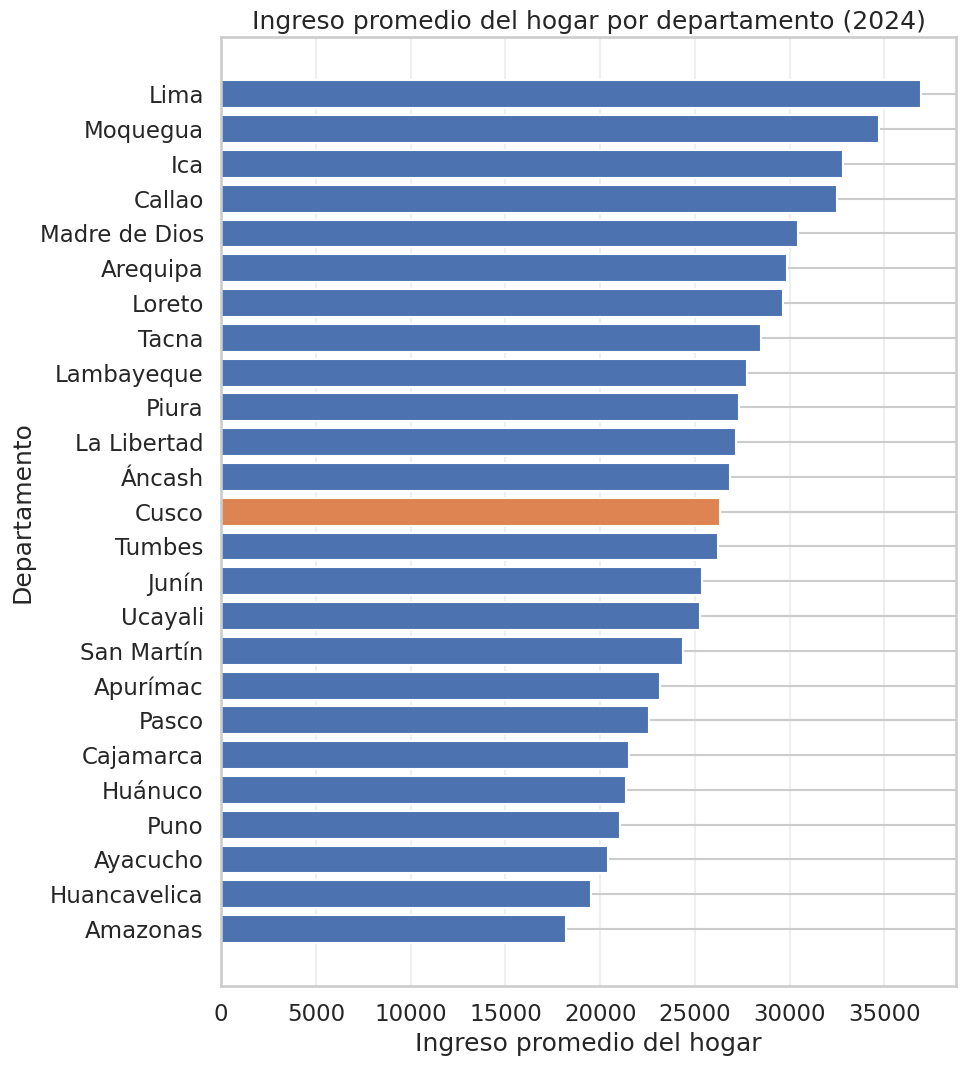

In [19]:
# Ranking de ingreso promedio del hogar

plot_df = corte_2024.sort_values("ingreso_prom_hogar", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(plot_df["departamento"], plot_df["ingreso_prom_hogar"])

# resaltar Cusco
mask = plot_df["cod_dpto"] == "08"
ax.barh(plot_df.loc[mask, "departamento"], plot_df.loc[mask, "ingreso_prom_hogar"])

ax.set_title(f"Ingreso promedio del hogar por departamento ({ANIO_CORTE})")
ax.set_xlabel("Ingreso promedio del hogar")
ax.set_ylabel("Departamento")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "08_ranking_ingreso_promedio_hogar_departamentos_2024.png")
plt.show()

Gráfico exportado: 09_ranking_pobreza_nbi_departamentos_2024.png


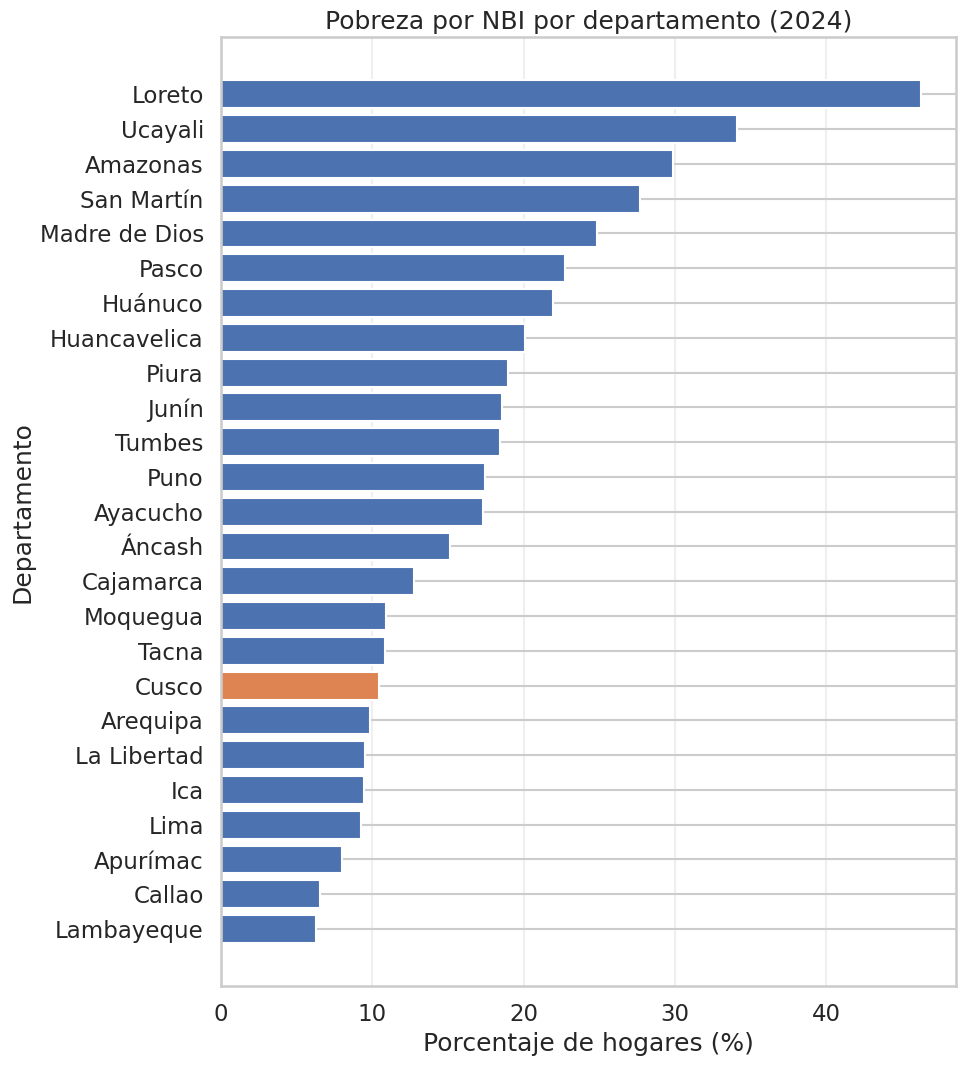

In [20]:
# Ranking de pobreza por NBI

plot_df = corte_2024.sort_values("pct_pobre_nbi_100", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(plot_df["departamento"], plot_df["pct_pobre_nbi_100"])

mask = plot_df["cod_dpto"] == "08"
ax.barh(plot_df.loc[mask, "departamento"], plot_df.loc[mask, "pct_pobre_nbi_100"])

ax.set_title(f"Pobreza por NBI por departamento ({ANIO_CORTE})")
ax.set_xlabel("Porcentaje de hogares (%)")
ax.set_ylabel("Departamento")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "09_ranking_pobreza_nbi_departamentos_2024.png")
plt.show()

Gráfico exportado: 10_ranking_participacion_hogar_departamentos_2024.png


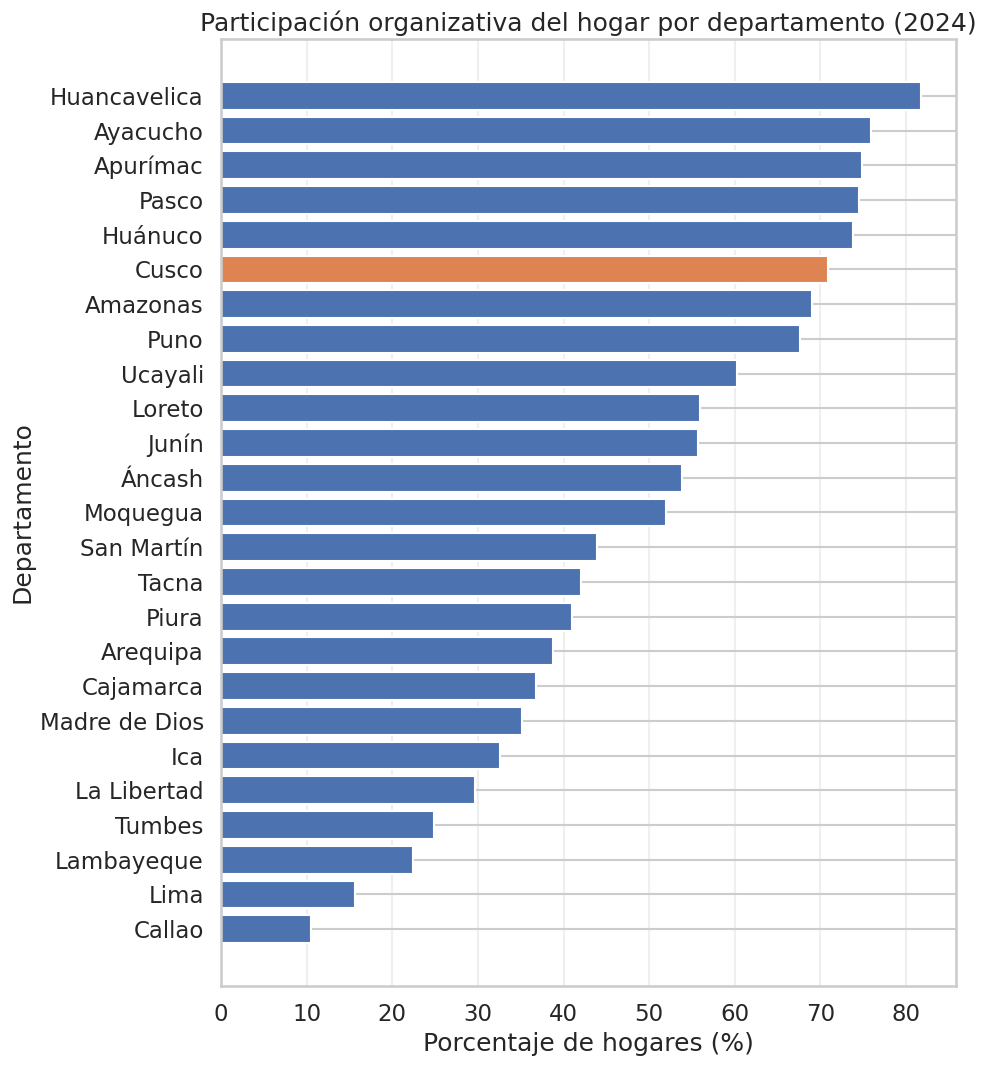

In [21]:
# Ranking de participación

plot_df = corte_2024.sort_values("pct_hogares_participa_100", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(plot_df["departamento"], plot_df["pct_hogares_participa_100"])

mask = plot_df["cod_dpto"] == "08"
ax.barh(plot_df.loc[mask, "departamento"], plot_df.loc[mask, "pct_hogares_participa_100"])

ax.set_title(f"Participación organizativa del hogar por departamento ({ANIO_CORTE})")
ax.set_xlabel("Porcentaje de hogares (%)")
ax.set_ylabel("Departamento")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "10_ranking_participacion_hogar_departamentos_2024.png")
plt.show()

## 6. Relaciones entre variables: exploración, no causalidad

Otra pregunta posible es: **¿Qué relación visible aparece entre ingreso, pobreza, participación y crecimiento del PIB a nivel departamento × año?** Aquí la visualización adecuada es la dispersión. Pero debemos recordar: una nube de puntos sugiere asociaciones, no demuestra causalidad.

Gráfico exportado: 11_dispersion_ingreso_vs_pobreza_nbi.png


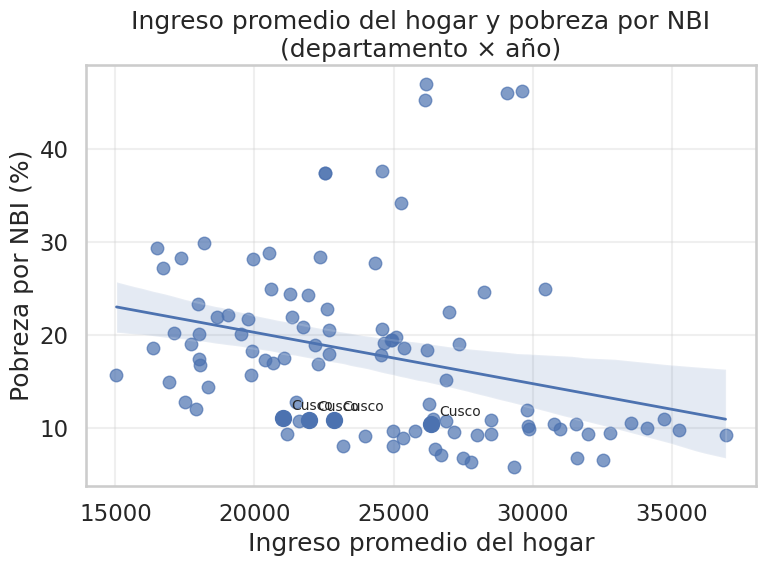

In [22]:
# Dispersión 1: ingreso vs pobreza por NBI

plot_df = viz_dpto.dropna(subset=["ingreso_prom_hogar", "pct_pobre_nbi_100"]).copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="ingreso_prom_hogar",
    y="pct_pobre_nbi_100",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2},
    ax=ax
)

resaltar_cusco(ax, "ingreso_prom_hogar", "pct_pobre_nbi_100", plot_df)

ax.set_title("Ingreso promedio del hogar y pobreza por NBI\n(departamento × año)")
ax.set_xlabel("Ingreso promedio del hogar")
ax.set_ylabel("Pobreza por NBI (%)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "11_dispersion_ingreso_vs_pobreza_nbi.png")
plt.show()

Gráfico exportado: 12_dispersion_pib_crecimiento_vs_ingreso.png


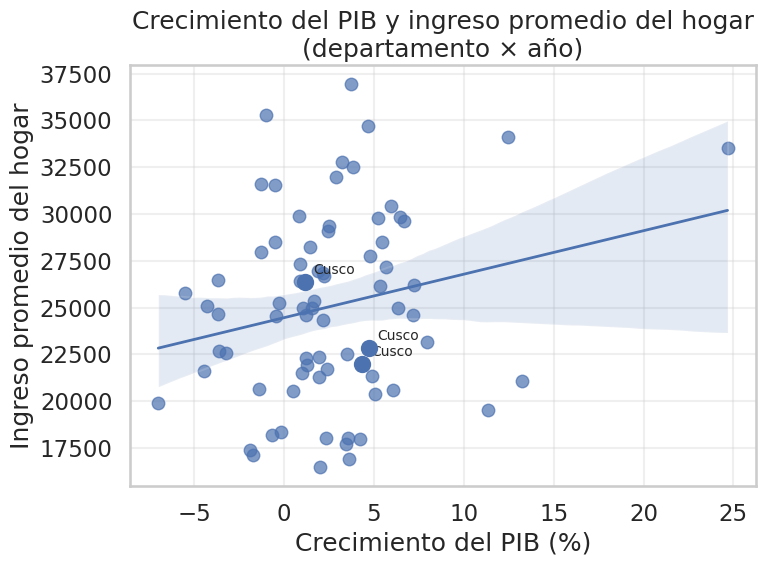

In [23]:
# Dispersión 2: crecimiento del PIB vs ingreso del hogar

plot_df = viz_dpto.dropna(subset=["pib_crecimiento", "ingreso_prom_hogar"]).copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="pib_crecimiento",
    y="ingreso_prom_hogar",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2},
    ax=ax
)

resaltar_cusco(ax, "pib_crecimiento", "ingreso_prom_hogar", plot_df)

ax.set_title("Crecimiento del PIB y ingreso promedio del hogar\n(departamento × año)")
ax.set_xlabel("Crecimiento del PIB (%)")
ax.set_ylabel("Ingreso promedio del hogar")
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "12_dispersion_pib_crecimiento_vs_ingreso.png")
plt.show()

Gráfico exportado: 13_dispersion_participacion_vs_pobreza_nbi.png


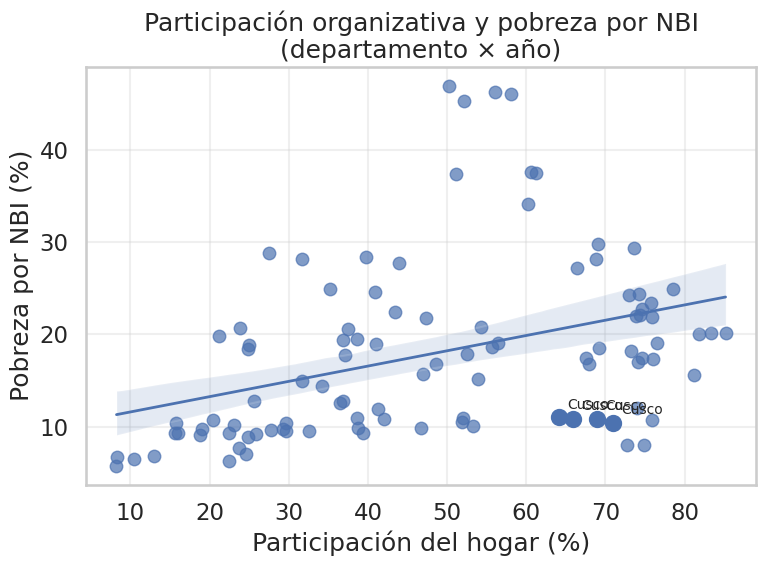

In [24]:
# Dispersión 3: participación y pobreza por NBI

plot_df = viz_dpto.dropna(subset=["pct_hogares_participa_100", "pct_pobre_nbi_100"]).copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="pct_hogares_participa_100",
    y="pct_pobre_nbi_100",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2},
    ax=ax
)

resaltar_cusco(ax, "pct_hogares_participa_100", "pct_pobre_nbi_100", plot_df)

ax.set_title("Participación organizativa y pobreza por NBI\n(departamento × año)")
ax.set_xlabel("Participación del hogar (%)")
ax.set_ylabel("Pobreza por NBI (%)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_fig(fig, "13_dispersion_participacion_vs_pobreza_nbi.png")
plt.show()

## 7. Matriz de correlación: lectura comparativa de estructura

La matriz de correlación no sustituye al análisis sustantivo.  
Pero sirve para una primera inspección del patrón general de asociación entre indicadores. Debe leerse con cautela por tres razones: combina departamentos y años; el número de observaciones es relativamente pequeño; y correlación no implica causalidad ni dirección del mecanismo.

In [25]:
vars_corr = [
    "ingreso_prom_hogar",
    "pct_pobre_nbi_100",
    "pct_hogares_participa_100",
    "pct_hogares_con_superior_100",
    "pib_crecimiento"
]

corr_df = viz_dpto[vars_corr].copy()
corr = corr_df.corr()

display(corr.round(3))

,ingreso_prom_hogar,pct_pobre_nbi_100,pct_hogares_participa_100,pct_hogares_con_superior_100,pib_crecimiento
ingreso_prom_hogar,1.000,-0.289,-0.590,0.859,0.217
pct_pobre_nbi_100,-0.289,1.000,0.373,-0.478,-0.032
pct_hogares_participa_100,-0.590,0.373,1.000,-0.685,0.082
pct_hogares_con_superior_100,0.859,-0.478,-0.685,1.000,0.094
pib_crecimiento,0.217,-0.032,0.082,0.094,1.000


Gráfico exportado: 14_heatmap_correlaciones_indicadores.png


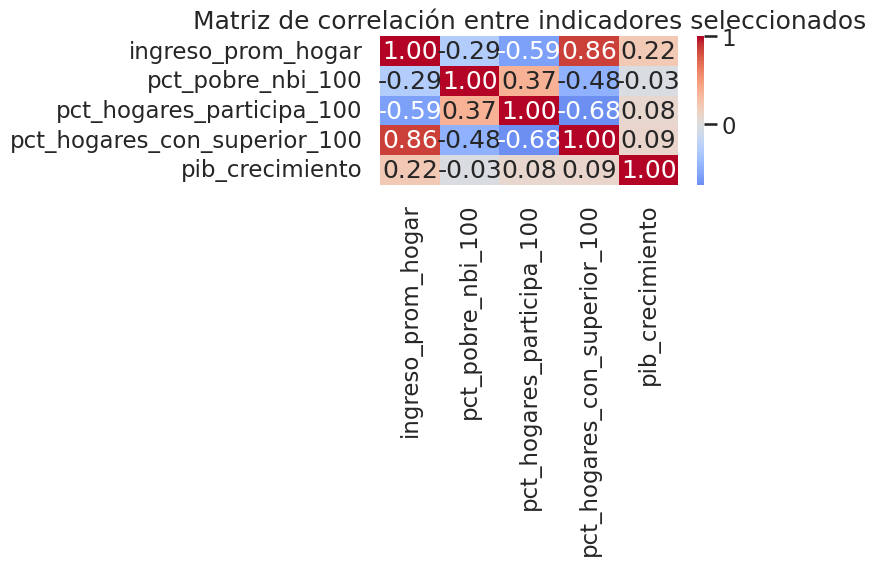

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación entre indicadores seleccionados")
plt.tight_layout()
guardar_fig(fig, "14_heatmap_correlaciones_indicadores.png")
plt.show()

## 8. Tabla corta para insumo narrativo

Un buen gráfico debe poder acompañarse de una tabla mínima de apoyo.  
Aquí construiremos un resumen breve de Cusco 2021–2024 útil para redacción posterior.

In [27]:
tabla_cusco = viz_cusco[[
    "anio",
    "ingreso_prom_hogar",
    "ingreso_mediano_hogar",
    "pct_pobre_nbi_100",
    "pct_hogares_participa_100",
    "pct_hogares_con_superior_100",
    "pib",
    "pib_crecimiento"
]].copy()

tabla_cusco = tabla_cusco.round(2)
display(tabla_cusco)

,anio,ingreso_prom_hogar,ingreso_mediano_hogar,pct_pobre_nbi_100,pct_hogares_participa_100,pct_hogares_con_superior_100,pib,pib_crecimiento
0,2021,"21,037.000","14,841.700",11.040,64.180,36.700,"20,592,202.000",NaN
1,2022,"21,960.450","15,342.000",10.870,65.860,36.820,"21,489,757.000",4.360
2,2023,"22,846.760","18,057.000",10.870,68.870,38.070,"22,507,388.000",4.740
3,2024,"26,348.060","19,272.000",10.410,70.890,41.140,"22,767,865.000",1.160


In [28]:
tabla_cusco.to_csv(RUTA_RESULTADOS_S3 / "tabla_resumen_cusco_2021_2024.csv", index=False, encoding="utf-8")
print("Tabla exportada: tabla_resumen_cusco_2021_2024.csv")

Tabla exportada: tabla_resumen_cusco_2021_2024.csv


## 9. Ejercicio aplicado

Con base en los gráficos producidos, responde brevemente:

1. ¿el ingreso promedio del hogar en Cusco sigue una trayectoria ascendente, descendente o inestable?
2. ¿la pobreza por NBI en Cusco se comporta de forma similar al agregado Perú?
3. ¿en qué posición aproximada queda Cusco frente a los demás departamentos en 2024?
4. ¿qué relación aparente observas entre ingreso y pobreza por NBI?
5. ¿qué cuidado metodológico debes tener antes de convertir esa relación visible en una afirmación causal?

### Pregunta de articulación con la Tarea 1

¿Cuál de estos ejes te parece más prometedor para desarrollar un análisis inicial más sólido sobre Cusco?

- ingresos y condiciones de vida;
- participación y pobreza;
- educación del hogar e ingresos;
- contexto macroeconómico y reproducción social.

## 10. Cierre del módulo

En esta sesión pasamos de la base analítica al argumento visual inicial.

### Lo logrado

- cargar resultados ya estructurados del módulo 2;
- transformar proporciones a escalas legibles;
- construir series temporales para Cusco;
- comparar Cusco con el agregado nacional;
- ubicar a Cusco frente al conjunto departamental;
- explorar asociaciones entre variables;
- exportar gráficos y tablas útiles para la Tarea 1.

### Regla metodológica consolidada

La secuencia correcta no es: **dato → gráfico → conclusión*, sino: **pregunta → estructura del dato → gráfico adecuado → interpretación prudente**. Eso es lo que convierte a la visualización en una herramienta de investigación y no solo de presentación.